# Objectif du notebook 

Date de création : 10/12/2025

L'objectif du notebook est de repositionner les OBS de la campagne de mesure du mois d'octobre 2025 à Groix dans le cadre du projet Fiberscope. 
Les OBS ont été déployés proche de la fibre reliant le continent à l'île de Groix. Leurs positions sont connues a priori (relèvement de la position GPS et position visée). 

Ce notebook vise à mettre en œuvre les outils nécessaires à l'inversion des positions sur un jeu de données fictives. Ces outils seront ensuite utilisés sur les données réelles dans un second notebook. 

## Approche générale 

Les positions des capteurs sont inversées par résolution d'un système de moindres carrés non linéaires formulé en fonction des : 

* 1) mesures des temps d'arrivée (TOA) dans le cas des émissions actives avec la source Lubell 
* 2) mesures des différences de temps d'arrivée (TDOA) dans le cas de l'exploitation de sources d'opportunités (bruit rayonné par les navires circulant dans la zone durant la campagne et dont la position est relevée par le système AIS)

### Définition du repère de référence 
Avant de mettre en œuvre le schéma d'inversion il est nécessaire de définir le repère de référence dans lequel on souhaite exprimer l'ensemble des coordonnées. 

Les positions de la source sont données par les données de l'antenne GPS à bord du navire. En positionnement standard le GPS fourni des positions dans le repère de référence WGS84. L'exactitude de ce positionnement est au mieux métrique. 

Quelques codes EPSG associés au WGS84 (cours géodésie Bosser p.92):
* 4978 : pour l’expression de coordonnées ECEF dans le WGS84
* 4326 : pour l’expression de coordonnées géographiques dans le WGS84


### Inversion des TOAs
L'approche la plus simple consiste à exploiter les TOAs. Le système des moindres carrés est exprimé en fonction de la distance de propagation au carré :

$$
y_k = d^2 = c^2 t_k^2
$$
 
où $t_k$ est le temps d'arrivée du direct pour la $k$-ème position de la source et $c$ est la célérité de référence (célérité moyenne, célérité équivalente).

Remarque : l'utilisation de la distance au carré permet de ne pas se trimbaler la racine pour le calcul de la matrice Jacobienne. 

<!-- 
On note $X_k$ la position 
$$
D_j^2 = \lVert P_jH_1\rVert^2 = (r_j - r)^2 + (z-z_j)^2 = (r_j - r)^2 + z^2   
$$

Pour la position de référence (j=0) : 

$$
(1) \quad \quad D_0^2 = (r_0 - r)^2 + z^2 = r_0^2 - 2r_0r + z^2  = z^2
$$

Or on peut écrire pour $j \in [1, 5]$ :

$$
(2) \quad \quad D_j^2 = (D_0 + \delta D_j)^2 = D_0^2 + 2D_0 \delta D_j + D_j^2
$$

Et, 

$$
(3) \quad \quad  D_0^2 + 2D_0 \delta D_j + D_j^2 =  r_j^2 - 2r_jr + z^2 
$$

Ainsi, on peut écrire (3) - (2) : 

$$
(4) \quad \quad  2D_0 \delta D_j + D_j^2 =  r_j^2 - 2r_jr
$$
 -->


In [1]:
import os 
import sys 
import numpy as np 
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt  

In [2]:
# project_root = "/home/program/ubf_tools"
project_root = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), "..", "..", ".."))
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(
    project_root, "real_data_analysis", "fiberscope_groix"
)
data_folder = os.path.join(root_folder, "data") 

In [3]:
sys.path.append(project_root)

from source.utils.utils_geo import (
    geodetic_to_ecef,
    ecef_to_enu,
    enu_to_ecef, 
    ecef_to_geodetic,
)


# from real_data_analysis.fiberscope_20.src import  params
from misc import equivalent_celerity, calc_wls, draw_ellipse
# from real_data_analysis.fiberscope_20.src.fiberscope_manager import FiberscopeManager
# from real_data_analysis.fiberscope_20.src.fiberscope_recording import (
#     FiberscopeSweep1,
#     # FiberscopeSweep2,
# )
# from real_data_analysis.fiberscope_20.src.utils import (
#     all_arrivals_static,
#     direct_arrival_env,
#     f_d2,
#     # f_d2_no_z,
#     jac_d2,
#     # jac_d2_no_z,
# )

from publication.publication_figure import PubFigure, color

# Définition du repère local 

## Chargement des positions a priori des OBS et des points d'émission statique. Les coordonnées sont a priori en WGS84.

In [4]:
# Chargement des positions a priori
apriori_pos_wgs84 = pd.read_csv(os.path.join(root_groix_metadata, "pos_deg.csv"), index_col=0)
# Ajout d'une hauteur (aléatoire pour l'instant)
# En vrai il faut surement chercher la hauteur du géoid au dessus de l'éllispoid WGS84
# et y retrancher l'immersion du capteur (immersion par rapport au niveau moyen de la mer donnée par
# la moyenne des mesures de pression du capteur de pression).
apriori_pos_wgs84["h"] = -25 + np.random.normal(
    loc=0, scale=1, size=apriori_pos_wgs84.shape[0]
)

In [5]:
apriori_pos_wgs84

,lat,lon,h
id,,,
obs1,47.661667,-3.470000,-28.046993
obs2,47.669167,-3.464167,-26.305996
obs3,47.676667,-3.460000,-25.746634
t1,47.661667,-3.467500,-26.364488
t2,47.661667,-3.456667,-22.971536
t3,47.661667,-3.445833,-25.041628
t4,47.661667,-3.433333,-25.712217
t5,47.661667,-3.420833,-24.557136


## Définition de l'origine du repère local

On construit un repère local ENU dont l'origine est confondue avec la position a priori de l'OBS2. Cet OBS est situé au milieu de la fibre, et donc de la zone d'intérêt, ce choix d'origine permet ainsi de réduire la distorsion engendrée par la projection dans ce repère local. 


In [6]:
# Coordonnées de le l'origine du repère de référence
obs_pos_id = "obs2"
pos0 = apriori_pos_wgs84.loc[obs_pos_id]
lat0 = np.radians(pos0.lat)
lon0 = np.radians(pos0.lon)
h0 = pos0.h    

### Calcul des coordonnées des OBS dans le repère local 

In [7]:
# WGS84 -> ECEF
lat = np.deg2rad(apriori_pos_wgs84.lat)
lon = np.deg2rad(apriori_pos_wgs84.lon)
X, Y, Z = geodetic_to_ecef(
    lat, lon, apriori_pos_wgs84.h
)
# ECEF -> ENU
e, n, u = ecef_to_enu(X, Y, Z, lat0, lon0, h0)

apriori_pos_enu = pd.DataFrame(np.stack((e, n, u)).T, index=apriori_pos_wgs84.index, columns=["e", "n", "u"])

In [8]:
apriori_pos_enu

,e,n,u
id,,,
obs1,-438.151263,-833.858418,-1.810594
obs2,0.000000,0.000000,0.000000
obs3,312.875640,833.884713,0.497123
t1,-250.372216,-833.869743,-0.117974
t2,563.337785,-833.848314,3.255054
t3,1377.047453,-833.712430,1.061430
t4,2315.943128,-833.414533,0.119563
t5,3254.839426,-832.965447,0.865427


## Illustration : calcul distance dans le repère local 

Afin d'illustrer la projection dans le repère local on calcule la distance du point de mesure T5 (cf rapport SHOM) à l'origine du repère précédemment défini.  

In [9]:
# Coordonnées du point T5
pos_id = "t5"
src_T5 = apriori_pos_wgs84.loc[pos_id]
lat = np.radians(src_T5.lat)
lon = np.radians(src_T5.lon)
h = -5

# WGS84 -> ECEF
X, Y, Z = geodetic_to_ecef(lat, lon, h)

# ECEF -> ENU
e, n, u = ecef_to_enu(X, Y, Z, lat0, lon0, h0)

print(f"E = {e}m, {n}m, {u}m")
dxy_to_obs = np.sqrt(e**2 + n**2)
print(f"D = {dxy_to_obs}m")

E = [3254.84938804]m, [-832.96800417]m, [20.42256029]m
D = [3359.74407281]m


# Génération d'un jeu de données synthétiques 

Afin de tester la procédure on considère un petit jeu de données synthétiques : 

* N positions incertaines de la source dans le repère WGS84 -> (lon, lat, h)
* N mesures bruitées du temps de propagation -> t


In [10]:
# Taille du dataset 
N = 20

## Génération des positions 

Afin de garantir que les positions générées sont situées dans la zone d'intérêt on génère des coordonnées dans le repère local dans un cercle de rayon R donné puis on convertit les coordonnées en WGS84. 

In [11]:
# Génération des positions dans le repère local
Rmax = 2 * 1e3      # 4 km 

r = np.random.uniform(0, Rmax, size=N) 
theta = np.random.uniform(0, 2*np.pi, size=N)
# print(r, theta)

x_s = r * np.cos(theta)
y_s = r * np.sin(theta)
marnage = 6
T_tide = 12 * 60 * 60 
omega_tide = 2 * np.pi / T_tide
t_max = 20 * 60 * 60
t = np.linspace(0, t_max, num=r.size)
z_s = 25 + marnage * np.sin(omega_tide * t)

Text(0, 0.5, 'z [m]')

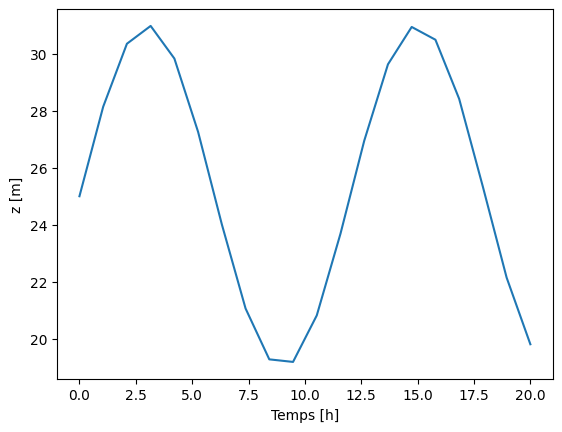

In [12]:
plt.figure()
plt.plot(t / 3600, z_s)
plt.xlabel("Temps [h]")
plt.ylabel("z [m]")

### Ajout de bruit sur les positions 

In [13]:
sigma_GPS = 5 # incertitude sur la position GPS en WGS84
sigma_x = sigma_GPS / np.sqrt(2)        # Hypothèse erreurs en x et y indépendantes et égales (sigma_x = sigma_y)
sigma_y = sigma_x
sigma_z = sigma_x

x_s_noisy = x_s + np.random.normal(loc=0, scale=sigma_x, size=x_s.size)
y_s_noisy = y_s + np.random.normal(loc=0, scale=sigma_y, size=y_s.size)
z_s_noisy = z_s + np.random.normal(loc=0, scale=sigma_z, size=z_s.size)

### Convertion en coordonnées WGS84

In [14]:
# Transformation en coordonnées WGS84
# ENU -> ECEF
X, Y, Z = enu_to_ecef(x_s, y_s, z_s, lat0, lon0, h0)
# ECEF -> WGS84
lat_s, lon_s, h_s = ecef_to_geodetic(X, Y, Z)
# Convert to deg
lat_s = np.rad2deg(lat_s)
lon_s = np.rad2deg(lon_s)

print(lon_s, lat_s, h_s)

[-3.44220717 -3.46277151 -3.46623525 -3.46627225 -3.47916395 -3.47776374
 -3.47392633 -3.444145   -3.46685387 -3.48471479 -3.46562043 -3.47719605
 -3.47324488 -3.46606926 -3.45286845 -3.45408437 -3.44597543 -3.45919284
 -3.46432308 -3.46703198] [47.66564302 47.66995474 47.6687747  47.66411459 47.68291952 47.67303426
 47.65777273 47.6673586  47.66696369 47.66201298 47.6791717  47.67217165
 47.66899126 47.67797814 47.6796485  47.66887439 47.66264647 47.66853779
 47.67127177 47.67799736] [-1.08111132  1.83750348  4.04956738  4.70023261  3.81135153  1.04796336
 -2.12555492 -5.06641091 -7.02452981 -6.88637325 -5.39171985 -2.53440098
  0.67860378  3.4024349   4.80006447  4.23359094  2.30016861 -0.96416693
 -4.15736955 -6.42286315]


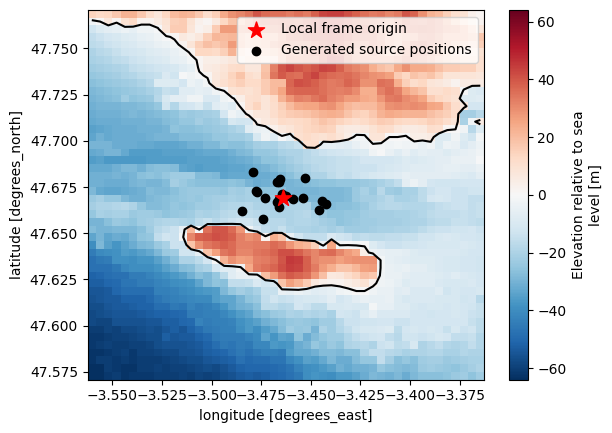

In [15]:
# Load bathy data
input_data_root = os.path.join(project_root, "data")
bathy_fpath = os.path.join(input_data_root, "bathy", "GEBCO_2021_sub_ice_topo.nc")
# bathy_fpath = r"/home/program/ubf_tools/data/bathy/mmdpm/PVA_RR48/GEBCO_2021_lon_64.44_67.44_lat_-29.08_-26.08.nc"

ds_bathy = xr.open_dataset(bathy_fpath)

# Slice data to get the area of interest
dlat_box = 0.1
dlon_box = 0.1
ds_bathy = ds_bathy.sel(
    lat=slice(
        pos0.lat - dlat_box,
        pos0.lat + dlat_box,
    ),
    lon=slice(
        pos0.lon - dlon_box,
        pos0.lon + dlon_box,
    ),
)

ds_bathy.elevation.plot()
# Add contours
plt.contour(
    ds_bathy.lon, ds_bathy.lat, ds_bathy.elevation, levels=[-0], colors="black"
)
# Repère local
plt.scatter(
    pos0.lon,
    pos0.lat,
    color="red",
    label="Local frame origin",
    marker="*",
    s=150,
    zorder=2
)
# Positions des sources
plt.scatter(lon_s, lat_s, color="black", label="Generated source positions", zorder=1)
plt.legend()

## Calcul des distances à l'OBS 1

In [16]:
obs_id = "obs1"
obs_pos = apriori_pos_enu.loc[obs_id]
e_0 = obs_pos.e
n_0 = obs_pos.n 
u_0 = obs_pos.u
sigma_e = 50    # m 
sigma_n = sigma_e 
sigma_u = 1     # m

print(f"OBS position a priori (e,n,u) = ({e_0}, {n_0}, {u_0})")
e = e_0 + np.random.normal(loc=0, scale=sigma_e) 
n = n_0 + np.random.normal(loc=0, scale=sigma_n)
u = u_0 + np.random.normal(loc=0, scale=sigma_u) 
print(f"OBS position a priori (e,n,u) = ({e}, {n}, {u})")

d_s = np.sqrt((e - x_s) ** 2 + (n - y_s) ** 2 + (u - z_s) ** 2)
d_s_noisy = np.sqrt((e - x_s_noisy) ** 2 + (n - y_s_noisy) ** 2 + (u - z_s_noisy) ** 2)

print(f"Distance au point {obs_id} (m) : {d_s}")

OBS position a priori (e,n,u) = (-438.15126291009216, -833.8584175393255, -1.8105940590760952)
OBS position a priori (e,n,u) = (-540.0235672064946, -846.0769283790546, -1.1455237125718702)
Distance au point obs1 (m) : [2236.15893324 1135.08568421  890.48637008  477.20849211 2446.69688388
 1364.13409688  463.57951468 2143.27925693  690.05375771 1004.87131553
 2005.43237781 1259.31453678  839.15305624 1868.72530524 2444.36589244
 1531.59274333 1910.46190318 1199.06017424 1202.62207989 1856.67439458]


## Calcul des temps d'arrivée


In [17]:
# Calcul du temps d'arrivée 
c = 1500
t_s = d_s / c
print(f"Temps d'arrivée (s) : {t_s}")

Temps d'arrivée (s) : [1.49077262 0.75672379 0.59365758 0.31813899 1.63113126 0.90942273
 0.30905301 1.42885284 0.46003584 0.66991421 1.33695492 0.83954302
 0.55943537 1.24581687 1.62957726 1.02106183 1.27364127 0.79937345
 0.80174805 1.23778293]


### Ajout du bruit sur les temps d'arrivée

In [18]:
sigma_t = 5 * 1e-3  # 5 ms 
t_s_noisy = t_s + np.random.normal(loc=0, scale=sigma_t, size=t_s.size)
print(f"Temps d'arrivée bruités (s) : {t_s_noisy}")

Temps d'arrivée bruités (s) : [1.48582057 0.76273349 0.60301479 0.31991696 1.63189731 0.91572117
 0.30075957 1.43376596 0.45702688 0.6757072  1.34836356 0.83591002
 0.54644538 1.24727417 1.63537169 1.02571789 1.27846444 0.79807342
 0.79748471 1.24023262]


## Sauvergarde des données générées 

In [19]:
# data_folder = "/home/program/ubf_tools/real_data_analysis/fiberscope_groix/data/synthetic_data"

ds_synthetic = xr.Dataset(
    data_vars=dict(
        x_no_noise = (["id"], x_s),
        y_no_noise = (["id"], y_s),
        z_no_noise = (["id"], z_s),
        x = (["id"], x_s_noisy),
        y = (["id"], y_s_noisy),
        z = (["id"], z_s_noisy),
        d_no_noise = (["id"], d_s),
        d = (["id"], d_s_noisy),
        t_arr_no_noise = (["id"], t_s),
        t_arr = (["id"], t_s_noisy),
    ),
    coords=dict(
        id=np.arange(x_s.size)
    ), 
    attrs=dict(
        sigma_gps=sigma_GPS,
        sigma_time=sigma_t,
    )
)

In [20]:
ds_synthetic

<xarray.Dataset> Size: 2kB
Dimensions:         (id: 20)
Coordinates:
  * id              (id) int32 80B 0 1 2 3 4 5 6 7 8 ... 12 13 14 15 16 17 18 19
Data variables:
    x_no_noise      (id) float64 160B 1.649e+03 104.8 -155.4 ... -11.75 -215.2
    y_no_noise      (id) float64 160B -391.5 87.62 -43.58 ... -69.91 234.1 981.8
    z_no_noise      (id) float64 160B 25.0 28.14 30.35 ... 25.33 22.14 19.8
    x               (id) float64 160B 1.651e+03 99.76 -157.7 ... -14.11 -218.4
    y               (id) float64 160B -390.2 94.57 -48.36 ... -66.9 232.0 981.7
    z               (id) float64 160B 18.38 31.89 26.12 ... 22.4 22.69 22.26
    d_no_noise      (id) float64 160B 2.236e+03 1.135e+03 ... 1.857e+03
    d               (id) float64 160B 2.238e+03 1.138e+03 ... 1.2e+03 1.856e+03
    t_arr_no_noise  (id) float64 160B 1.491 0.7567 0.5937 ... 0.8017 1.238
    t_arr           (id) float64 160B 1.486 0.7627 0.603 ... 0.7981 0.7975 1.24
Attributes:
    sigma_gps:   5
    sigma_time:  0.005

In [21]:
synthetic_data_folder = os.path.join(data_folder, "synthetic_data")
if not os.path.exists(synthetic_data_folder):
    os.makedirs(synthetic_data_folder)
fpath = os.path.join(synthetic_data_folder, f"synthetic_data_{N}pos.nc")
ds_synthetic.to_netcdf(fpath)

# Chargement des données 

A partir d'ici on implémente les outils de traitement indépendamment de la source des données (synthétiques ou réelles). 


In [22]:
# # Real data
# fname = f"real_dataset_name.nc"
# Synthetic data
fname = f"synthetic_data_{N}pos.nc"     


# Le fichier de données doit contenir les positions de la sources aux instants d'émission ainsi que les temps de propagation associés.
fpath = os.path.join(synthetic_data_folder, fname)
ds_arrivals = xr.open_dataset(fpath)
ds_arrivals.close()

# Estimation de la position par moindres carrés

#### Définition du problème des moindres carrés non linéaire 

In [23]:
def f(X, X_s):
    """
    Parameters
    ----------
    X : array
        [y, x, z] position of the hydrophone to estimate in the local reference frame
    X_s : 2D array
        [y, x, z] positions of the source

    """
    x, y, z = X
    x_s, y_s, z_s = X_s[:, 0], X_s[:, 1], X_s[:, 2]
    d2 = (x - x_s) ** 2 + (y - y_s) ** 2 + (z - z_s) ** 2
    return d2


def jac(X, X_s):
    """
    Parameters
    ----------
    X : array
        [y, x, z] position of the hydrophone to estimate in the local reference frame
    X_s : 2D array
        [y, x, z] positions of the source
    """
    x, y, z = X
    x_s, y_s, z_s = X_s[:, 0], X_s[:, 1], X_s[:, 2]

    df_dx = 2 * (x - x_s)
    df_dy = 2 * (y - y_s)
    df_dz = 2 * (z - z_s)
    J = np.array([df_dx, df_dy, df_dz]).T
    return J

## Résolution

In [24]:
# Initialisation des données 
c = 1500 # TODO : remplacer par une valeur représentative du vrai profil (<c(z)> ou bien c_eq)
# Position a priori 
X_0 = np.array([e_0, n_0, u_0])
# Position succesives de la source 
X_s = np.stack((ds_arrivals.x.values, ds_arrivals.y.values, ds_arrivals.z.values)).T
# Grandeur signante 
y = (ds_arrivals.t_arr.values * c) ** 2

In [25]:
# Weighting matrix
# W = np.diag(1 / y_var)
W = np.eye(len(y))     # Initialisation avec la matrice identité 


X_hat, dY_hat, cost_hat, SigmaXhat, sigma02hat = calc_wls(Y=y, t=X_s, X_0=X_0, W=W, fct=f, jac=jac,tol=1e-6, verbose=False)
print(f"True position : x = {e}, y = {n}, z = {u}")
print(f"Estimated position : x = {X_hat[0]}, y = {X_hat[1]}, z = {X_hat[2]}")
print(f"Residuals : {dY_hat}")
print(f"Final cost : {cost_hat}")
print(SigmaXhat)

True position : x = -540.0235672064946, y = -846.0769283790546, z = -1.1455237125718702
Estimated position : x = -544.4462913455316, y = -853.4501283700207, z = -2.266112846547429
Residuals : [-74751.97997083 -16357.01986764   9927.18387579 -11344.68446175
 -33698.6828945   -6220.79328164 -11236.54784321  25764.13636638
 -23183.19950417  16084.43019157  36993.06725087 -37131.13263286
 -55700.37615409 -27216.42416      6916.64427756  -7236.75945852
  -1192.73830337 -38710.86158975 -38059.58661422 -21814.74490108]
Final cost : 14903256818.87094
[[ 1.45937871e+01  2.25015578e+00 -9.18965358e+01]
 [ 2.25015578e+00  2.27842999e+01 -2.24962221e+02]
 [-9.18965358e+01 -2.24962221e+02  3.54595434e+03]]


## Représentation des résultats 

### Positionnement horizontal (2D)

c:\Users\baptiste.menetrier\Desktop\devPy\phd\misc.py:797: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'N [m]')

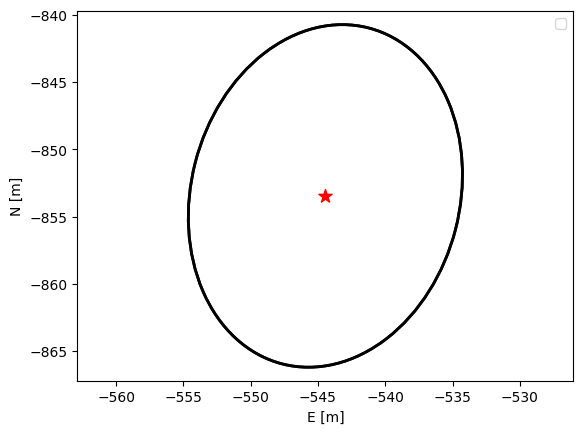

In [26]:
plt.figure()
# Origine du repère locale 
# plt.scatter(
#     0, 
#     0, 
#     label=fr"O ($\lambda$ = {{{np.round(pos0.lon, 1)}}}°, $\phi$ = {{{np.round(pos0.lat, 1)}}}°, $h$ = {{{np.round(pos0.h, 1)}}}m)"
# )
# Position estimée 
plt.scatter(
    X_hat[0],
    X_hat[1],
    marker="*",
    s=100,
    color="r",
    # label=r"$\hat{" + obs_id + r"}$",
    zorder=2,
)

 # Ellipse de confiance
alpha = 0.95
# nombre d'observations
nobs = y.shape[0]
# nombre de paramètres inconnus
nparams = 2
ddl = nobs - nparams 
draw_ellipse(X=X_hat[0:2], SigmaX=SigmaXhat[0:2, 0:2], ddl=ddl, alpha=alpha, title="", color="k", fac=1)

ax = plt.gca()
ax.axis("equal")
plt.xlabel("E [m]")
plt.ylabel("N [m]")


#### Sauvegarde des résultats

In [27]:
# # Save estimated positions
# df_hydro_pos = pd.DataFrame.from_dict(hydro_pos_hat, orient="index", columns=["r", "z"])
# # Set Hi column as index 
# df_hydro_pos.index.name = "h_index"
# df_hydro_pos.to_csv(os.path.join(params.root_data, "hydro_positions", "hydrophones_estimated_positions.csv"))

# BILAN 



### Localisation des hydrophones par TDOA 

On cherche à estimer la position $\begin{pmatrix} r \\ z \end{pmatrix}$ de l'hydrophone, par exemple $H_1$.

On dispose des enregistrements correspondant aux positions de la source de $P_0$ à $P_5$ noté $P_j \begin{pmatrix} r_j \\ z_j \end{pmatrix}$. L'origine du repère est choisie en $P_0$ de telle sorte que $r_j = j \times \Delta_r, z_j = 0$, $j \in [0, 5]$.

Soit $j \in [0, 5]$,

$$
D_j^2 = \lVert P_jH_1\rVert^2 = (r_j - r)^2 + (z-z_j)^2 = (r_j - r)^2 + z^2   
$$

Pour la position de référence (j=0) : 

$$
(1) \quad \quad D_0^2 = (r_0 - r)^2 + z^2 = r_0^2 - 2r_0r + z^2  = z^2
$$

Or on peut écrire pour $j \in [1, 5]$ :

$$
(2) \quad \quad D_j^2 = (D_0 + \delta D_j)^2 = D_0^2 + 2D_0 \delta D_j + D_j^2
$$

Et, 

$$
(3) \quad \quad  D_0^2 + 2D_0 \delta D_j + D_j^2 =  r_j^2 - 2r_jr + z^2 
$$

Ainsi, on peut écrire (3) - (2) : 

$$
(4) \quad \quad  2D_0 \delta D_j + D_j^2 =  r_j^2 - 2r_jr
$$

En pratique on mesure des différences de temps d'arrivée $\delta T_j = T_j - T_0$, $\delta D_j = c \delta T_j$. 

Et donc (4) s'écrit :
$$
(4) \quad \quad  2D_0 c \delta T_j + (c \delta T_j)^2 =  r_j^2 - 2r_jr
$$

On a donc 3 inconnues ($D_0, c, r$) pour 5 équations ($j \in [1, 5]$).

